In [ ]:
pip install pyspark

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("forestfires.csv") \
    .getOrCreate()

In [ ]:
df = spark.read.csv("forestfires.csv", header=True, inferSchema=True)
df.show(5)


+---+---+-----+---+----+----+-----+---+----+---+----+----+----+
|  X|  Y|month|day|FFMC| DMC|   DC|ISI|temp| RH|wind|rain|area|
+---+---+-----+---+----+----+-----+---+----+---+----+----+----+
|  7|  5|  mar|fri|86.2|26.2| 94.3|5.1| 8.2| 51| 6.7| 0.0| 0.0|
|  7|  4|  oct|tue|90.6|35.4|669.1|6.7|18.0| 33| 0.9| 0.0| 0.0|
|  7|  4|  oct|sat|90.6|43.7|686.9|6.7|14.6| 33| 1.3| 0.0| 0.0|
|  8|  6|  mar|fri|91.7|33.3| 77.5|9.0| 8.3| 97| 4.0| 0.2| 0.0|
|  8|  6|  mar|sun|89.3|51.3|102.2|9.6|11.4| 99| 1.8| 0.0| 0.0|
+---+---+-----+---+----+----+-----+---+----+---+----+----+----+
only showing top 5 rows


In [ ]:
rdd = df.rdd

temp_rdd = rdd.map(lambda x: x['temp'])

avg_temp = temp_rdd.mean()

print("Average Temperature:", avg_temp)

Average Temperature: 18.889168278529997


In [ ]:
month_area = rdd.map(lambda x: (x['month'], x['area'])) \
                .reduceByKey(lambda a, b: a + b)

month_area.collect()

[('mar', 235.26000000000002),
 ('oct', 99.57),
 ('aug', 2297.99),
 ('sep', 3086.129999999998),
 ('apr', 80.02000000000001),
 ('jun', 99.29999999999998),
 ('jul', 459.83),
 ('feb', 125.5),
 ('jan', 0.0),
 ('dec', 119.97),
 ('may', 38.48),
 ('nov', 0.0)]

In [ ]:
day_count = rdd.map(lambda x: (x['day'], 1)) \
               .reduceByKey(lambda a, b: a + b)

day_count.collect()

[('fri', 85),
 ('tue', 64),
 ('sat', 84),
 ('sun', 95),
 ('mon', 74),
 ('wed', 54),
 ('thu', 61)]

In [ ]:
df.createOrReplaceTempView("forestfires")

In [ ]:
spark.sql("""
SELECT month, AVG(temp) as avg_temp
FROM forestfires
GROUP BY month
""").show()

+-----+------------------+
|month|          avg_temp|
+-----+------------------+
|  jun| 20.49411764705882|
|  aug| 21.63152173913045|
|  may|             14.65|
|  feb| 9.634999999999998|
|  sep| 19.61220930232558|
|  mar|13.083333333333337|
|  oct|17.093333333333337|
|  jul|22.109375000000004|
|  nov|              11.8|
|  apr|12.044444444444444|
|  dec| 4.522222222222222|
|  jan|              5.25|
+-----+------------------+



In [ ]:
spark.sql("""
SELECT *
FROM forestfires
WHERE temp > 30 AND wind > 5
""").show()

+---+---+-----+---+----+-----+-----+----+----+---+----+----+----+
|  X|  Y|month|day|FFMC|  DMC|   DC| ISI|temp| RH|wind|rain|area|
+---+---+-----+---+----+-----+-----+----+----+---+----+----+----+
|  8|  6|  aug|sun|94.9|130.3|587.1|14.1|31.0| 27| 5.4| 0.0| 0.0|
+---+---+-----+---+----+-----+-----+----+----+---+----+----+----+



In [ ]:
spark.sql("""
SELECT day, SUM(area) as total_area
FROM forestfires
GROUP BY day
ORDER BY total_area DESC
""").show()

+---+------------------+
|day|        total_area|
+---+------------------+
|sat|2144.8600000000006|
|thu|             997.1|
|sun| 959.9299999999998|
|tue|            807.79|
|mon| 706.5300000000001|
|wed|             578.6|
|fri|            447.24|
+---+------------------+



In [ ]:
spark.sql("""
SELECT *
FROM forestfires
ORDER BY area DESC
LIMIT 5
""").show()

+---+---+-----+---+----+-----+-----+----+----+---+----+----+-------+
|  X|  Y|month|day|FFMC|  DMC|   DC| ISI|temp| RH|wind|rain|   area|
+---+---+-----+---+----+-----+-----+----+----+---+----+----+-------+
|  6|  5|  sep|sat|92.5|121.1|674.4| 8.6|25.1| 27| 4.0| 0.0|1090.84|
|  8|  6|  aug|thu|94.8|222.4|698.6|13.9|27.5| 27| 4.9| 0.0| 746.28|
|  7|  4|  jul|mon|89.2|103.9|431.6| 6.4|22.6| 57| 4.9| 0.0| 278.53|
|  1|  2|  sep|tue|91.0|129.5|692.6| 7.0|18.8| 40| 2.2| 0.0| 212.88|
|  2|  2|  sep|sat|92.5|121.1|674.4| 8.6|18.2| 46| 1.8| 0.0| 200.94|
+---+---+-----+---+----+-----+-----+----+----+---+----+----+-------+



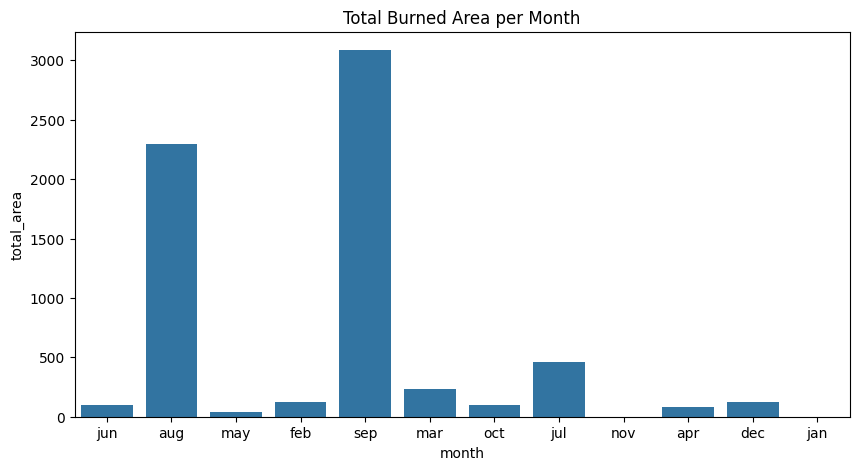

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark → Pandas
month_area_df = spark.sql("""
SELECT month, SUM(area) as total_area
FROM forestfires
GROUP BY month
""").toPandas()

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x='month', y='total_area', data=month_area_df)
plt.title("Total Burned Area per Month")
plt.show()

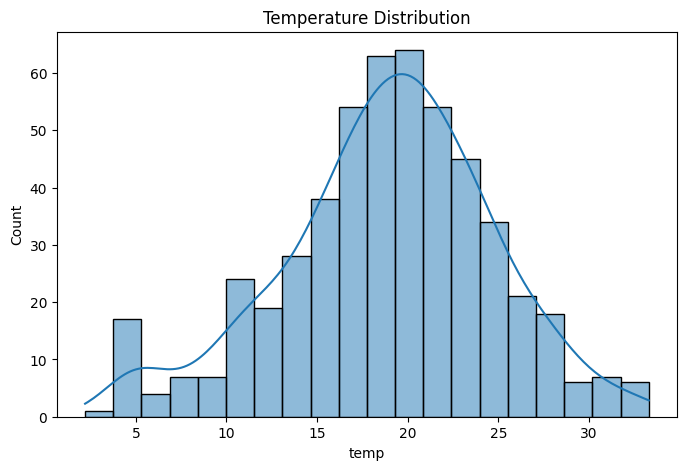

In [ ]:
temp_df = df.select("temp").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(temp_df['temp'], bins=20, kde=True)
plt.title("Temperature Distribution")
plt.show()

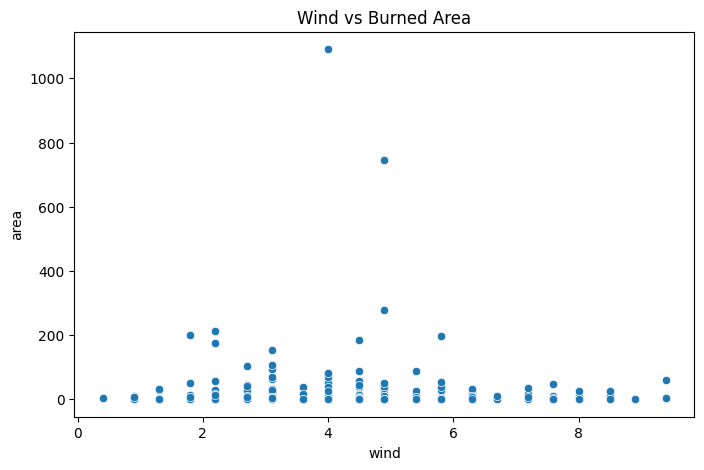

In [ ]:
wind_area_df = df.select("wind", "area").toPandas()

plt.figure(figsize=(8,5))
sns.scatterplot(x='wind', y='area', data=wind_area_df)
plt.title("Wind vs Burned Area")
plt.show()

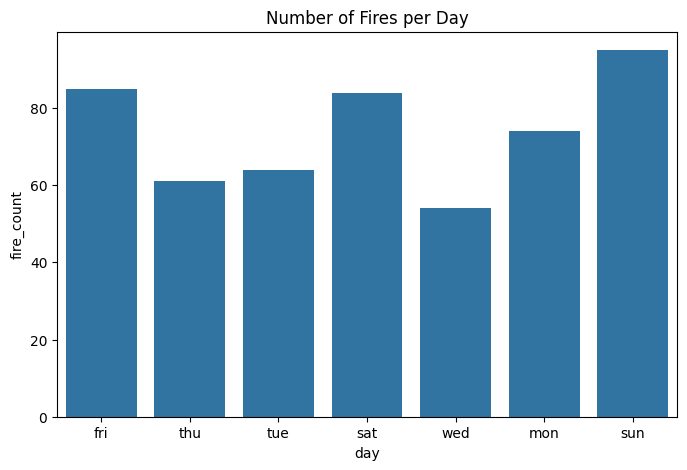

In [ ]:
day_count_df = spark.sql("""
SELECT day, COUNT(*) as fire_count
FROM forestfires
GROUP BY day
""").toPandas()

plt.figure(figsize=(8,5))
sns.barplot(x='day', y='fire_count', data=day_count_df)
plt.title("Number of Fires per Day")
plt.show()

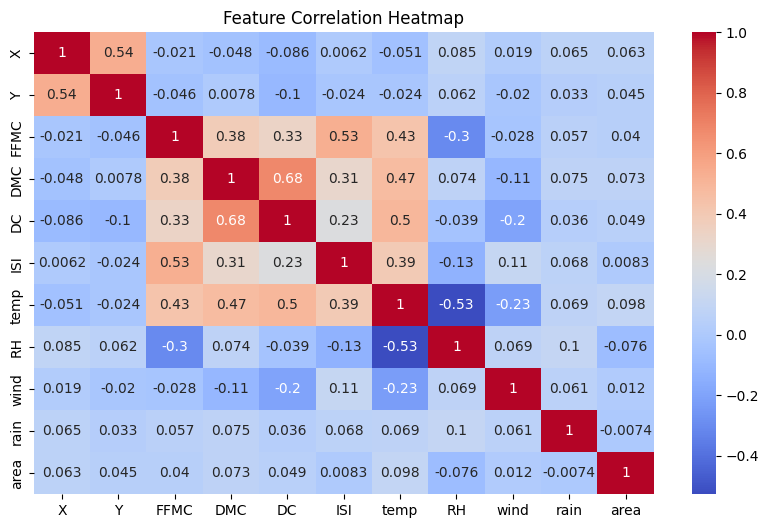

In [ ]:
corr_df = df.toPandas()

# Select only numeric columns
numeric_df = corr_df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()